# Reproducing the CHC Western-Indian-Ocean / RONI Outlook for OND 2026

*A worked walk-through of the CHC / FEWS&nbsp;NET companion deck — "IOD, Western
Indian Ocean & RONI outlook for June 2026" (Laura Harrison & Chris Funk) —
rebuilt with the `rosetta` and `deepscale` libraries.*

---

### What the deck argues

East Africa's **October–December (OND) "short rains"** are strongly controlled by
the state of the two neighbouring oceans. The deck's case for 2026 is that the
ocean is moving toward the configuration that most reliably produces *extreme*
short rains: a **strong El&nbsp;Niño** in the Pacific, a **strong positive Indian
Ocean Dipole (IOD)**, and an **exceptionally warm western Indian Ocean pole**
(the deck's slide 3: *"expected… very warm (>29°C)"*) that supplies moisture
onshore. The deck's headline comparison is that OND 2026 resembles **1997 and
2023** (slide 2), with **2015 and 2019** in a broader set of warm-western-pole
analog years.

### What this notebook builds — and on which data

The workflow uses only **`rosetta`** for data acquisition and **`deepscale`** for
the analysis. It goes figure by figure, in the deck's slide order.

Two fidelity notes. **(1)** The deck averages **six** NMME models; here we use the
three with a full 1991–2020 hindcast and a live June-2026 OND forecast available
through `rosetta` — CanSIPS-IC4, CCSM4, and CESM1. Two of the three (CCSM4, CESM1)
share NCAR/CESM lineage, so the effective ensemble diversity is a little lower than
"three models" suggests. **(2)** ERSSTv5 is the observed SST, as in the deck.

## Setup

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
import rosetta
import deepscale as ds
import deck_style as deck          # CHC palettes / marker styles, sampled from the deck legends

BASELINE = (1991, 2020)            # the deck's climatological reference period
YEARS  = list(range(1991, 2026))   # the hindcast record the forecast is scored against
TARGET = 2026                      # the season being forecast
EEA    = [-5, 12, 36, 52]          # eastern East Africa box (Kenya, Somalia, S/E Ethiopia) for rainfall

## 1 · The ocean data — a single `fetch`

The observed record is **ERSSTv5**, the series CHC uses, fetched over OPeNDAP in
one call (Rosetta also guards NOAA's silent zero-fill-on-over-large-request
failure mode). We reduce SST to the **October–December** seasonal mean per year:

In [3]:
sst = rosetta.fetch("obs/ersst-v5", "sst", hindcast=(1991, 2026), verbose=False)["sst"]
ond = sst.sel(time=sst.time.dt.month.isin([10, 11, 12])).groupby("time.year").mean("time")
print("OND-mean SST, one field per year:", dict(ond.sizes))

OND-mean SST, one field per year: {'year': 35, 'lat': 89, 'lon': 180}


## 2 · Reducing SST to three indices

Three scalar indices per year, each a DeepScale **`Index`** (which boxes, how each
is transformed, how they combine). RONI is catalogued; the dipole and the western
pole we define explicitly:

In [4]:
roni = ds.Index.named("roni", baseline=BASELINE).reduce(ond)     # relative Oceanic Niño index

# Indian Ocean Dipole (Saji et al. 1999): west pole minus east pole, each an SST anomaly (°C).
dmi_index = ds.Index.custom(
    name="dmi",
    regions={"west": [-10, 10, 50, 70], "east": [-10, 0, 90, 110]},
    combine=lambda box: box["west"] - box["east"],
    transform="anomaly", weights="cos_lat", baseline=BASELINE)

# Western Indian Ocean pole in ABSOLUTE °C, for the deck's ~29 °C threshold.
wio_index = ds.Index.custom(
    name="wio", regions={"west": [-10, 10, 50, 70]},
    combine=lambda box: box["west"], transform="raw", weights="cos_lat")

iod = dmi_index.reduce(ond)
wio = wio_index.reduce(ond)

table = pd.DataFrame({"RONI (°C)": roni.to_series(), "IOD (°C)": iod.to_series(),
                      "WIO (°C)": wio.to_series()}).round(2)
table.loc[[1997, 2015, 2019, 2023]]

,RONI (°C),IOD (°C),WIO (°C)
year,,,
1997,1.93,1.14,28.639999
2015,1.93,0.35,29.120001
2019,0.21,1.23,28.920000
2023,1.23,1.25,29.190001


The table tracks the deck's reasoning — 1997 strong on RONI, 2019 a strong dipole
with a modest El&nbsp;Niño, all four warm on WIO — **with one flag the deck's own
numbers carry: 2015's IOD is weak** (a decaying dipole), so 2015 qualifies as an
analog only through the absolute WIO temperature, not the dipole. We return to
that in the final section; it is the deck's choice, faithfully reproduced here.

## 2b · The rainfall outcomes — restoring the link the figure is *about*

The deck's flagship scatter is not a plot of ocean states; it is a plot of ocean
states **coloured by the East-African short-rains outcome each one produced**
(deck slide 2: *"The colors of points indicate the rainfall tercile outcomes for
the eastern East Africa region, based on CHIRPS3 data and a 1991-2020 baseline"*).
That colouring is the entire scientific claim — "the upper-right ocean state is
where the wet extremes fall." We compute it from CHIRPS over the eastern-East-Africa
box, as an OND regional-mean per year, categorised into terciles against the
1991–2020 climatology:

In [5]:
rain = rosetta.fetch("obs/chirps-v3-monthly", "precip", months=[10, 11, 12], seasonal="mean",
                     region=EEA, hindcast=(1991, 2025), allow_partial=True, verbose=False)["precip"]
rain = rain.mean(["lat", "lon"]).dropna("year")                  # EEA regional-mean OND rate per year

clim = rain.sel(year=slice(BASELINE[0], BASELINE[1]))
t33, t67 = float(clim.quantile(1/3)), float(clim.quantile(2/3))
rain_tercile = xr.where(rain < t33, "Below", xr.where(rain > t67, "Above", "Normal"))
rain_tercile.name = "EEA OND rainfall tercile"

print(f"EEA OND rainfall terciles (1991-2020 baseline: below<{t33:.2f}, above>{t67:.2f} mm/day)")
for cat in ["Above", "Normal", "Below"]:
    yrs = [int(y) for y, c in zip(rain.year.values, rain_tercile.values) if c == cat]
    print(f"  {cat:6s}: {yrs}")

EEA OND rainfall terciles (1991-2020 baseline: below<1.34, above>1.87 mm/day)
  Above : [1994, 1997, 2000, 2002, 2004, 2006, 2011, 2013, 2015, 2019, 2023]
  Normal: [1992, 1999, 2003, 2008, 2009, 2012, 2014, 2017, 2018, 2020, 2024]
  Below : [1991, 1993, 1995, 1996, 1998, 2001, 2005, 2007, 2010, 2016, 2021, 2022, 2025]


This is the observed rainfall context. Note where the deck's four analog years
land: they should be the **Above**-tercile (wet) years if the ocean-state argument
holds — that is the relationship the scatter is meant to display.

## 3 · From model output to a calibrated forecast

The deck's *forecast* for OND 2026 comes from the **NMME**, run from a June start.
We fetch each model's OND SST forecast, average across models, reduce to the same
three indices, and calibrate: **`quantile_map`** onto the observed distribution,
**`error_bounds`** for the 80% interval. This is exactly the CHC forecast recipe —
(1) average each model's simulations, (2) average the models, (3) quantile-map to
the final forecast — with one reorder that is mathematically identical for a linear
regional mean (we take the regional average after the model average). The Pacific
index is genuine **RONI** (Niño-3.4 anomaly *minus the 20°S–20°N tropical mean*,
L'Heureux et&nbsp;al. 2024) — not ONI. Two properties the final section revisits:
the quantile map uses the deck-default `extrapolate="clamp"`, and the interval is
built from in-sample 1991–2020 forecast errors (§6a, §6b).

In [6]:
MODELS = ["nmme/cansipsic4", "nmme/ccsm4", "nmme/cesm1"]

def nmme_ond_sst(year):
    fields = []
    for m in MODELS:
        d = rosetta.fetch(m, "sst", init=f"{year}-06", target="OND", region=[-25, 25, 0, 360],
                          hindcast=(year, year), verbose=False)["sst"]   # tropical band covers all index boxes
        if d.sizes.get("init_time", 0) == 0:            # provider gap for this model-year -> skip
            continue
        f = d.isel(init_time=0).mean("member")
        if float(np.nanmax(np.abs(f))) > 0:             # drop an all-zero (NMME zero-fill) field
            fields.append(f)
    return xr.concat(xr.align(*fields, join="inner"), dim="model").mean("model")   # mean over available models

fc_sst = xr.concat([nmme_ond_sst(y) for y in YEARS + [TARGET]],
                   dim=pd.Index(YEARS + [TARGET], name="year"))

def calibrate(index_obj, observed, extrapolate="clamp"):
    fc   = index_obj.reduce(fc_sst)
    hind = list(range(BASELINE[0], BASELINE[1] + 1))
    fc_h, obs_h = fc.sel(year=hind), observed.sel(year=hind)
    corrected = ds.quantile_map(fc, fc_h, obs_h, extrapolate=extrapolate)
    corrected = xr.DataArray(corrected, dims="year", coords={"year": fc.year})
    bounds = ds.error_bounds(corrected.sel(year=hind), obs_h,
                             float(corrected.sel(year=TARGET)), level=0.8)
    return corrected, bounds

roni_fc, roni_b = calibrate(ds.Index.named("roni", baseline=BASELINE), roni)
iod_fc,  iod_b  = calibrate(dmi_index, iod)
wio_fc,  wio_b  = calibrate(wio_index, wio)

for name, fc, b in [("RONI", roni_fc, roni_b), ("IOD", iod_fc, iod_b), ("WIO", wio_fc, wio_b)]:
    v = float(fc.sel(year=TARGET))
    print(f"  2026 {name:4s} forecast = {v:+6.2f} °C   [80% CI {float(b.lower):+.2f}, {float(b.upper):+.2f}]")

  2026 RONI forecast =  +1.93 °C   [80% CI +1.21, +2.69]
  2026 IOD  forecast =  +1.23 °C   [80% CI +0.85, +1.66]
  2026 WIO  forecast = +29.12 °C   [80% CI +28.89, +29.34]


## 4 · The figures

In [7]:
def obs_vs_forecast(observed, forecast, title, ylabel):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    yrs = observed.year.values
    ax.plot(yrs, observed.sel(year=yrs), color="#1f77b4", lw=1.8, marker="o", ms=3, label="Observed (ERSSTv5)")
    ax.plot(forecast.year.values, forecast, color="#111", lw=1.4, marker="o", ms=3, label="Forecast (NMME, bias-corrected)")
    ax.axvspan(BASELINE[0], BASELINE[1], color="#000", alpha=0.05, zorder=0)   # training window shaded
    ax.scatter([TARGET], [float(forecast.sel(year=TARGET))], color="#d62728", s=90, zorder=5, label="2026")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=3, frameon=False); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()

### Slide 2 · RONI vs IOD, coloured by rainfall outcome

The deck's summary slide places every historical year on a **forecast** RONI (x) vs **forecast** IOD (y) plane — the quantile-matched forecasts, not observations — colours each point by the observed eastern-East-Africa OND rainfall tercile it produced, and marks the 2026 forecast with 80% whiskers.

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
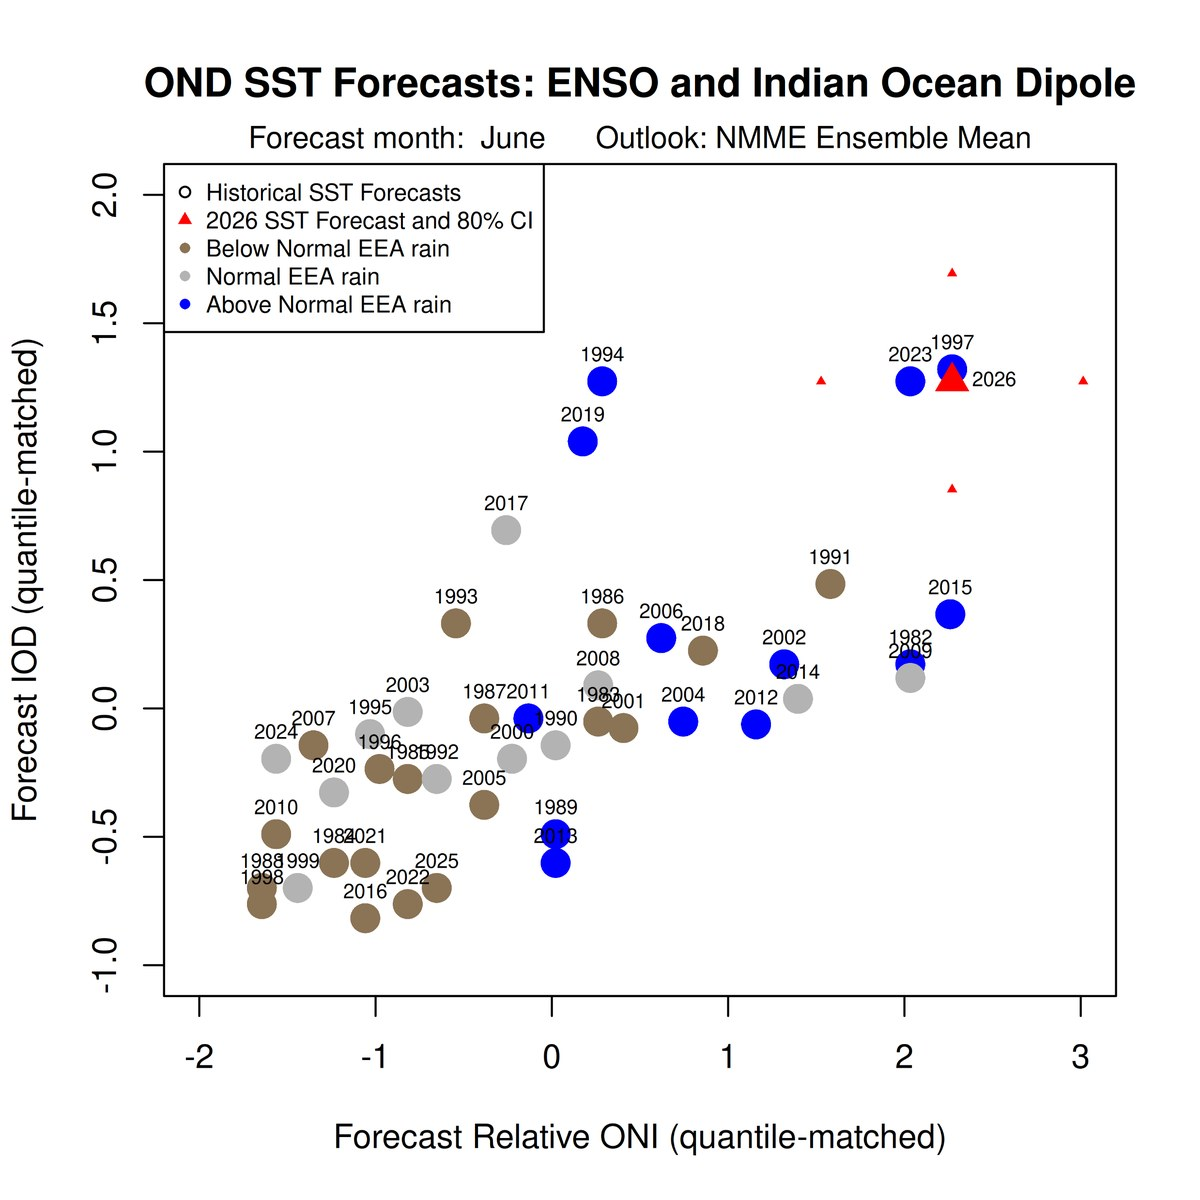
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 2</b> &mdash; OND SST Forecasts: ENSO and Indian Ocean Dipole (RONI vs IOD, June forecast)</figcaption>
</figure>

The axes are the **quantile-matched forecasts** `roni_fc` / `iod_fc` (as the deck's are), and the points are **coloured by the observed rainfall tercile** computed in §2b.

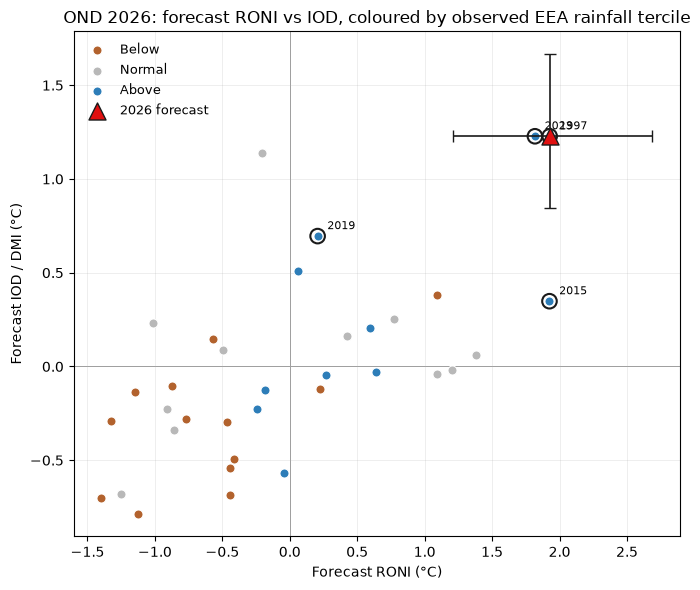

In [8]:
hist_yrs = rain_tercile.year                                     # historical years with an observed rainfall outcome
fig = ds.plot_index_scatter(
    roni_fc.sel(year=hist_yrs), iod_fc.sel(year=hist_yrs),       # FORECAST axes (deck), 2026 drawn as the triangle
    color_by=rain_tercile, categories=["Below", "Normal", "Above"],
    colors=["#b2622d", "#b8b8b8", "#2d7db8"],                    # dry / normal / wet
    highlight=[1997, 2015, 2019, 2023],
    forecast=(float(roni_fc.sel(year=TARGET)), float(iod_fc.sel(year=TARGET))),
    error_bars=(roni_b, iod_b),
    forecast_marker="^", forecast_color="#e01010", forecast_label="2026 forecast",
    xlabel="Forecast RONI (°C)", ylabel="Forecast IOD / DMI (°C)",
    title="OND 2026: forecast RONI vs IOD, coloured by observed EEA rainfall tercile")
plt.show()

Now the figure makes the deck's actual claim: the **wet (blue) years cluster in
the upper-right**, and the 2026 forecast falls among them — closest to **1997 and
2023** (the deck's headline pair). The colouring also makes visible what the
index table flagged: **2015 sits low on the IOD axis**, an outlier among the four
circled analogs in the very dimension the argument privileges — so its inclusion
rests on the western-pole temperature alone.

### Slide 3 · Western Indian Ocean SST — observed vs forecast

The forecast rises to near the top of the record. That the metric is an *absolute* temperature on a warming trend is the deck's choice — examined in the final section.

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
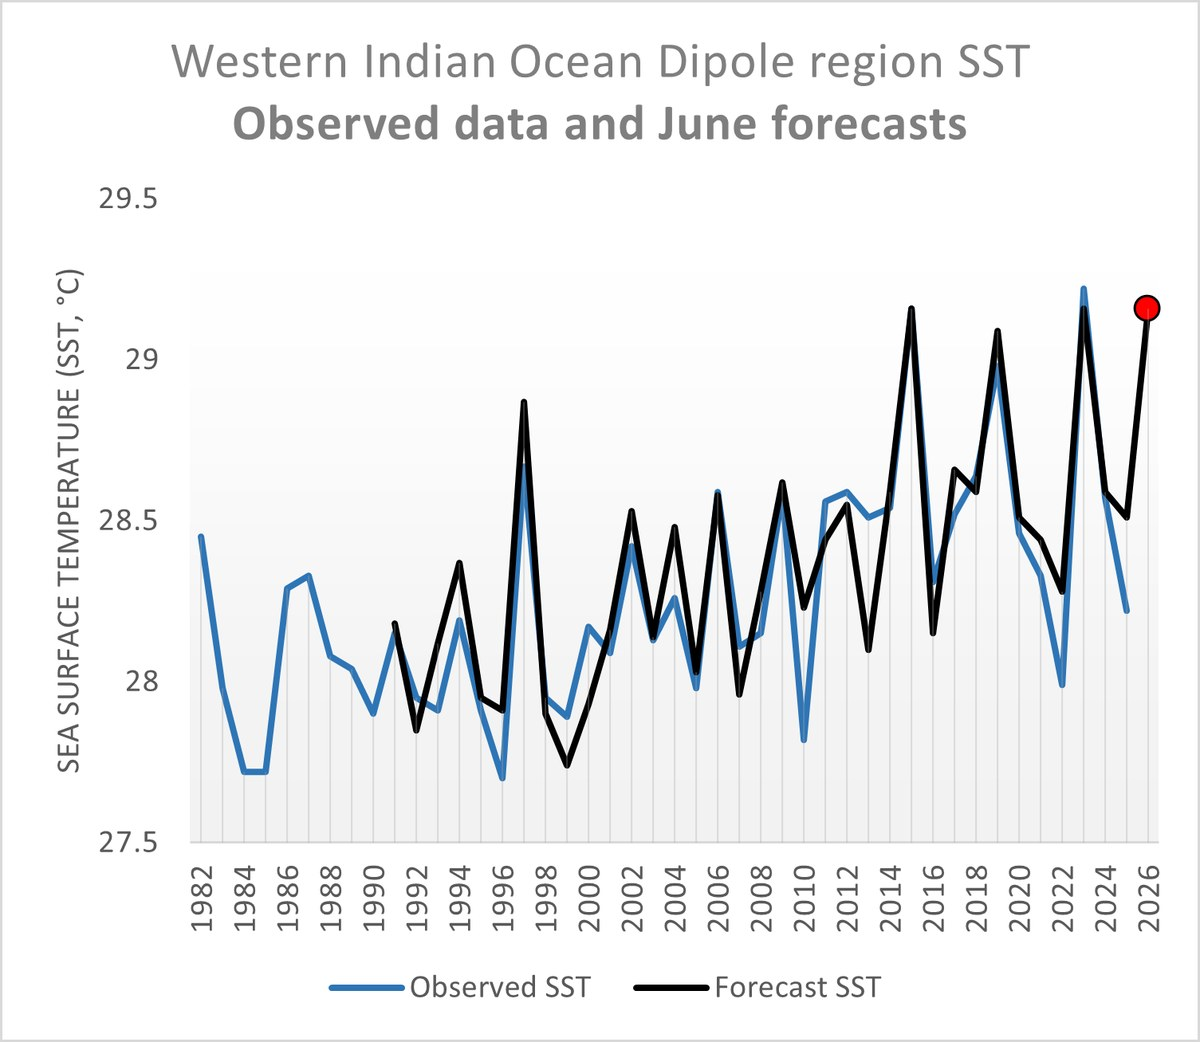
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 3</b> &mdash; Western Indian Ocean Dipole region SST — observed data and June forecasts</figcaption>
</figure>

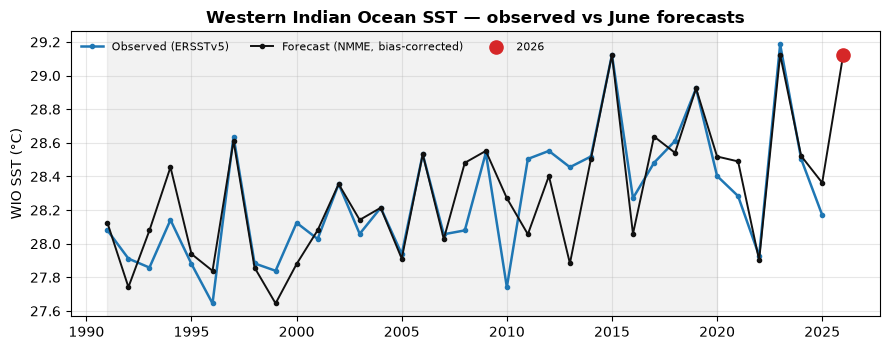

2026 WIO forecast: 29.12 °C (deck threshold ~29 °C)


In [9]:
obs_vs_forecast(wio, wio_fc, "Western Indian Ocean SST — observed vs June forecasts", "WIO SST (°C)")
print(f"2026 WIO forecast: {float(wio_fc.sel(year=TARGET)):.2f} °C (deck threshold ~29 °C)")

### Slide 4 · Indian Ocean Dipole — observed vs forecast

2026 sits among the strongest positive-dipole years. The confidence of a *June-initialised* OND-IOD forecast is the subject of the final section.

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
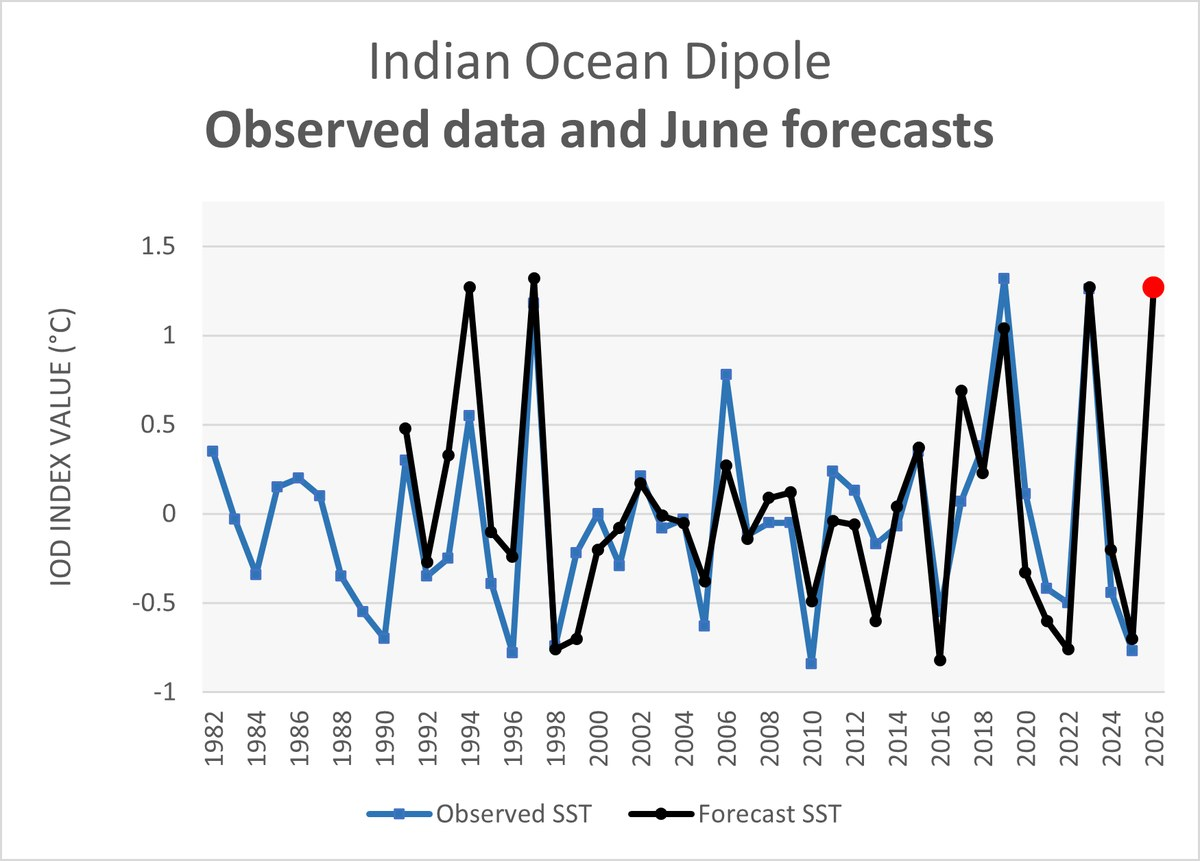
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 4</b> &mdash; Indian Ocean Dipole — observed data and June forecasts</figcaption>
</figure>

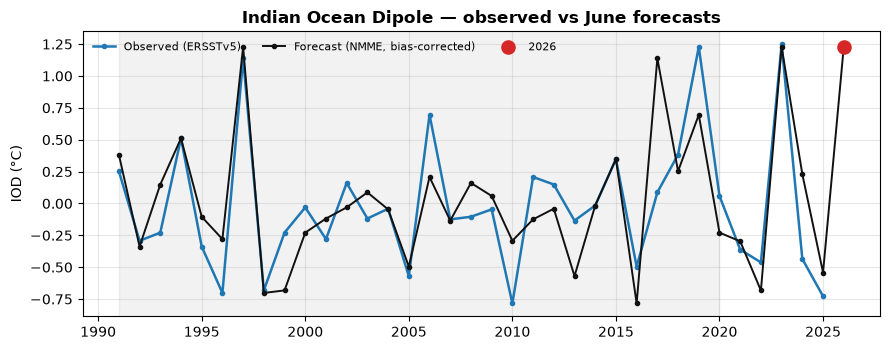

2026 IOD forecast: +1.23 °C


In [10]:
obs_vs_forecast(iod, iod_fc, "Indian Ocean Dipole — observed vs June forecasts", "IOD (°C)")
print(f"2026 IOD forecast: {float(iod_fc.sel(year=TARGET)):+.2f} °C")

### Slide 5 · Relative Oceanic Niño Index — observed vs forecast

2026 is forecast as one of the strongest RONI years. Note the value sits *exactly* at the historical maximum — a fingerprint of the clamped quantile map, taken up in the final section.

<figure style="margin:1.1em 0;padding:0.6em;border:1px solid #ddd;border-radius:8px;background:#fafafa">
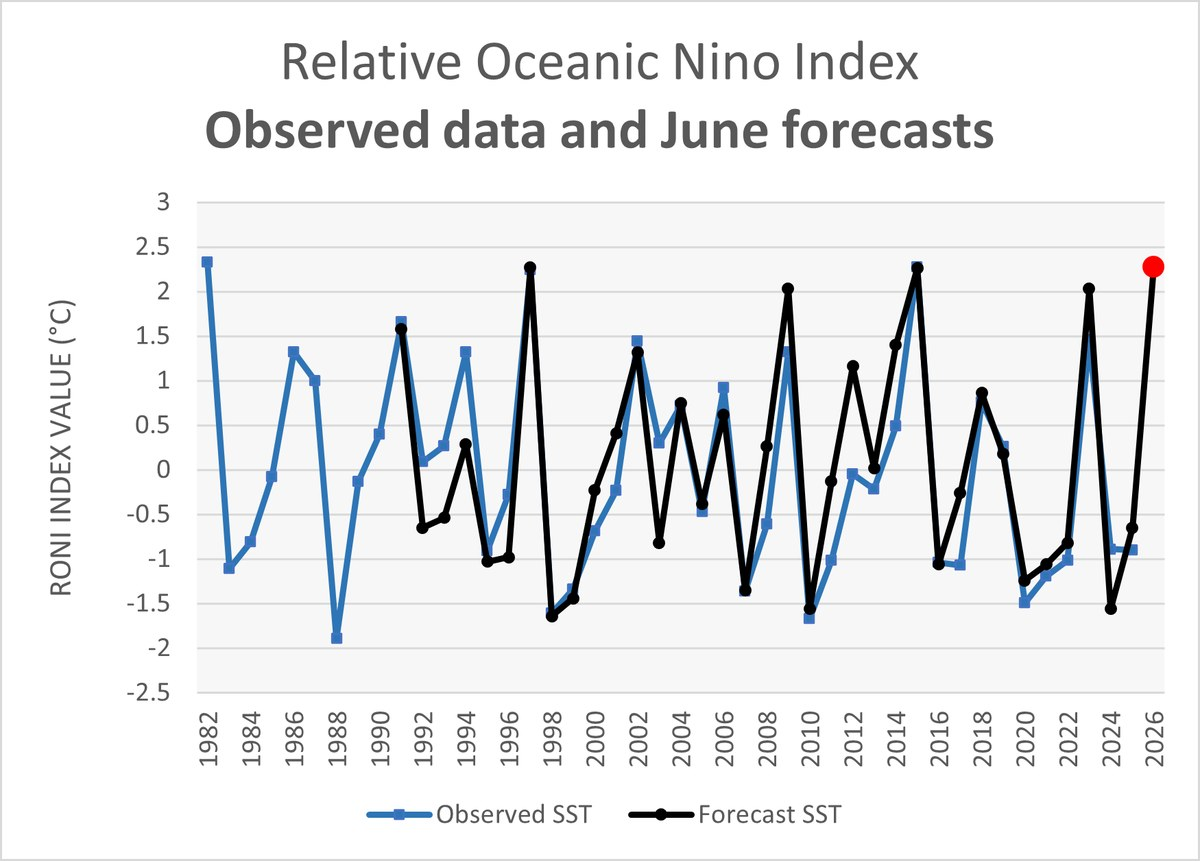
<figcaption style="font-size:0.85em;color:#555;margin-top:0.4em">
<b>CHC deck &middot; slide 5</b> &mdash; Relative Oceanic Niño Index — observed data and June forecasts</figcaption>
</figure>

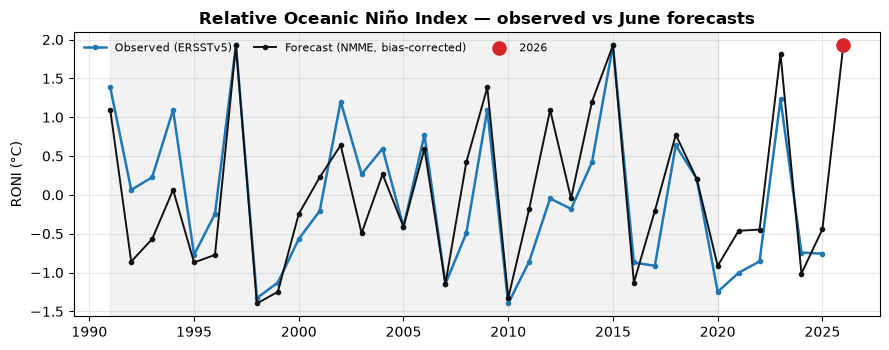

2026 RONI forecast: +1.93 °C


In [11]:
obs_vs_forecast(roni, roni_fc, "Relative Oceanic Niño Index — observed vs June forecasts", "RONI (°C)")
print(f"2026 RONI forecast: {float(roni_fc.sel(year=TARGET)):+.2f} °C")

## 5 · The analog years — the deck's rule, reproduced (descriptively)

The deck names **1997, 2015, 2019, 2023**. A simple threshold rule recovers that
list; since the thresholds are chosen to match the published set, it is a
*description* of the deck's analogs rather than an independent test. It is worth
showing how sharp the selection is:

In [12]:
for thr in [1.0, 1.1, 1.2]:
    u = ds.analogs_where(iod > thr) | ds.analogs_where(wio > 29.0)
    print(f"  IOD>{thr:.1f} | WIO>29.0  -> {sorted(u.years.tolist())}")
print("  deck's stated set        -> [1997, 2015, 2019, 2023]")

  IOD>1.0 | WIO>29.0  -> [1997, 2015, 2019, 2023]
  IOD>1.1 | WIO>29.0  -> [1997, 2015, 2019, 2023]
  IOD>1.2 | WIO>29.0  -> [2015, 2019, 2023]
  deck's stated set        -> [1997, 2015, 2019, 2023]


The set is not sharp: a slightly looser dipole threshold pulls in more years. The
deck's four are a reasonable *description* of the strong-signal end of the record,
not a bright line — and 2015 depends entirely on the WIO clause.

---

## 6 · Beyond the deck — four methodological notes

The reproduction above follows the deck's method. This short section revisits five
choices in it: the clamped quantile map (and when to un-clamp), the in-sample error
bounds, why the absolute WIO threshold is the physically right one, the
June-initialised IOD forecast skill, and an out-of-sample bake-off of the forecast
recipe itself.

### 6a · Clamped vs extrapolated quantile mapping

`quantile_map` defaults to `extrapolate="clamp"`, which caps a forecast beyond the
training range at the strongest event in that range. A strong-El-Niño June forecast
exceeds the 1991–2020 hindcast maximum, so the clamped RONI lands on the observed
record; `extrapolate="linear"` continues the transfer function past it:

In [13]:
roni_lin, roni_lb = calibrate(ds.Index.named("roni", baseline=BASELINE), roni, extrapolate="linear")
iod_lin,  iod_lb  = calibrate(dmi_index, iod, extrapolate="linear")
wio_lin,  wio_lb  = calibrate(wio_index,  wio, extrapolate="linear")

print(f"{'index':5s} {'clamped':>10s} {'linear':>10s}   (2026 forecast)")
for name, c, l in [("RONI", roni_fc, roni_lin), ("IOD", iod_fc, iod_lin), ("WIO", wio_fc, wio_lin)]:
    print(f"{name:5s} {float(c.sel(year=TARGET)):>+10.2f} {float(l.sel(year=TARGET)):>+10.2f}")

index    clamped     linear   (2026 forecast)
RONI       +1.93      +1.93
IOD        +1.23      +1.70
WIO       +29.12     +32.70


Under clamping the RONI and IOD forecasts sit at the historical maximum; linear
extrapolation lets 2026 exceed it. So "comparable to the strongest years" partly
reflects the clamp rather than the raw forecast. For WIO — an absolute temperature
on a warming trend — clamping to the 1991–2020 maximum is a mild low bias, since
some post-2020 observed years already exceed it.

Which choice is *right* depends on lead time and the early-warning posture, and the
CHC would reasonably make different calls at different stages. In June, with OND far
off, the clamped forecast is the conservative (but still alarming) long-lead call.
By August, with RONI already very high and near-certain to warm further by OND, the
un-clamped forecast — letting 2026 exceed the historical range — is the more
defensible one. Clamp is not the universally correct default; it is the cautious
long-lead default.

### 6b · In-sample vs cross-validated error bounds

The 80% interval uses residuals of the quantile-matched hindcast over the same
1991–2020 used to fit the map, which empirical quantile mapping shrinks by
construction. A leave-one-year-out (LOYO) interval — refit without year *k*,
predict *k* — gives an out-of-sample estimate:

In [14]:
def loyo_halfwidth(index_obj, observed, level=0.8):
    fc = index_obj.reduce(fc_sst); hind = list(range(BASELINE[0], BASELINE[1] + 1))
    errs = []
    for yr in hind:
        tr = [y for y in hind if y != yr]
        pred = ds.quantile_map(fc.sel(year=[yr]), fc.sel(year=tr), observed.sel(year=tr), extrapolate="linear")
        errs.append(float(np.asarray(pred).ravel()[0]) - float(observed.sel(year=yr)))
    lo, hi = np.quantile(errs, [(1 - level) / 2, 1 - (1 - level) / 2])
    return (hi - lo) / 2

for name, idx, obs, b in [("RONI", ds.Index.named("roni", baseline=BASELINE), roni, roni_b),
                          ("IOD", dmi_index, iod, iod_b), ("WIO", wio_index, wio, wio_b)]:
    insample = (float(b.upper) - float(b.lower)) / 2
    print(f"  {name:4s}  in-sample ±{insample:.2f} °C   ->   LOYO ±{loyo_halfwidth(idx, obs):.2f} °C")

  RONI  in-sample ±0.74 °C   ->   LOYO ±0.84 °C
  IOD   in-sample ±0.41 °C   ->   LOYO ±0.45 °C


  WIO   in-sample ±0.22 °C   ->   LOYO ±0.30 °C


The cross-validated intervals are somewhat wider, so the in-sample bounds are a
lower estimate of the June-initialised forecast uncertainty.

### 6c · Why absolute WIO warmth is the right index (not a trend-relative one)

It is tempting to argue that, on a basin that has warmed ~1 °C since the 1980s, the
WIO's raw 29 °C threshold just selects recent years, and that a *trend-relative*
western pole (warmth above the tropical mean, the logic RONI applies to the Pacific)
would be more discriminating. The data says otherwise — and it is worth showing why,
because it clarifies the physics:

In [15]:
wio_anom = ds.Index.custom(name="wio_anom", regions={"west": [-10, 10, 50, 70]},
                           combine=lambda b: b["west"], transform="anomaly",
                           weights="cos_lat", baseline=BASELINE).reduce(ond)
trop     = ds.Index.custom(name="trop", regions={"trop": [-20, 20, 0, 360]},
                           combine=lambda b: b["trop"], transform="anomaly",
                           weights="cos_lat", baseline=BASELINE).reduce(ond)
wio_rel  = wio_anom - trop     # western pole warmth ABOVE the tropical-mean warming

comp = pd.DataFrame({"WIO abs (°C)": wio.to_series().round(2),
                     "WIO rel-to-tropics (°C)": wio_rel.to_series().round(2),
                     "IOD (°C)": iod.to_series().round(2),
                     "EEA rain": pd.Series({int(y): str(c) for y, c in zip(rain.year.values, rain_tercile.values)})})
comp.loc[[1997, 2015, 2019, 2023]]

,WIO abs (°C),WIO rel-to-tropics (°C),IOD (°C),EEA rain
1997,28.639999,-0.03,1.14,Above
2015,29.120001,0.23,0.35,Above
2019,28.920000,0.37,1.23,Above
2023,29.190001,0.25,1.25,Above


The trend-relative metric **fails**: 1997 — one of the wettest OND seasons on record
(the East African floods) — has the *weakest* relative warmth of the four (≈−0.03 °C,
essentially at the tropical mean), while its absolute WIO is a perfectly wet-regime
28.6 °C. So relative-to-tropics warmth does not discriminate the wet years; if
anything it points the wrong way. The physically grounded reading is the one CHC
uses: **absolute WIO SST past ~28–29 °C** sets the convective / precipitable-water
background (deep convection over tropical oceans switches on near this SST, so it is
a real threshold, not a warming artefact), and what separates the four warm years is
the **Indian-Ocean dipole gradient** — note 2015's IOD is only ~0.35 °C versus
~1.1–1.25 °C for 1997/2019/2023. 2015's short rains were the least extreme of the
four precisely because its eastern pole was not cold, so there was no strong gradient
and no positive IOD — not because its western pole was, on any useful metric,
unremarkable.

### 6d · June-initialised forecast skill by index

The outlook rests on June-initialised NMME forecasts of the OND ocean state. A June
start sits just before the Indian Ocean's boreal-summer IOD growth phase — the
predictability barrier, across which dynamical OND-IOD skill is typically lower than
OND-ENSO skill. Scoring the bias-corrected forecast against observations over the
hindcast:

In [16]:
hind = list(range(BASELINE[0], BASELINE[1] + 1))
for name, fc, obs in [("RONI", roni_fc, roni), ("IOD", iod_fc, iod), ("WIO", wio_fc, wio)]:
    r = float(np.corrcoef(fc.sel(year=hind).values, obs.sel(year=hind).values)[0, 1])
    print(f"  June-init OND {name:4s} hindcast skill (corr, 1991-2020): r = {r:+.2f}")

  June-init OND RONI hindcast skill (corr, 1991-2020): r = +0.84
  June-init OND IOD  hindcast skill (corr, 1991-2020): r = +0.75
  June-init OND WIO  hindcast skill (corr, 1991-2020): r = +0.81


The IOD's June-initialised skill is the *lowest* of the three (r≈0.75 vs ≈0.81 for
WIO and ≈0.84 for RONI) — but "lowest" here is still high. An r≈0.75 for a
*June-initialised* OND-IOD forecast, made across the boreal-summer predictability
barrier, is genuinely impressive; much of it is inherited from ENSO (RONI, the most
skillful term, forces the IOD through the Pacific–Indian coupling). So the
strong-positive IOD carries the most forecast uncertainty of the three, and would
firm up further from an August/September start — but the June skill is a point in the
outlook's favour, not against it.

### 6e · Does the recipe choice change forecast skill? (out-of-sample bake-off)

Eyeballing the RONI time series invites the question of whether a different recipe
would track observations better. Test it *out-of-sample*: leave one year out, refit
the quantile map on the rest, predict the held-out year, and correlate the held-out
predictions with observations. Three ENSO-index recipes — our clamped RONI, the same
un-clamped, and a plain absolute Niño-3.4 (ONI, no tropical-mean subtraction):

In [17]:
def loyo_skill(index_obj, observed, extrapolate):
    fc = index_obj.reduce(fc_sst); hind = list(range(BASELINE[0], BASELINE[1] + 1))
    preds = []
    for yr in hind:
        tr = [y for y in hind if y != yr]
        p = ds.quantile_map(fc.sel(year=[yr]), fc.sel(year=tr), observed.sel(year=tr), extrapolate=extrapolate)
        preds.append(float(np.asarray(p).ravel()[0]))
    return float(np.corrcoef(preds, observed.sel(year=hind).values)[0, 1])

oni_obs = ds.Index.named("oni", baseline=BASELINE).reduce(ond)     # absolute Nino-3.4 anomaly (ONI)
for name, idx, obs, ex in [
        ("RONI, clamp (deck recipe)", ds.Index.named("roni", baseline=BASELINE), roni, "clamp"),
        ("RONI, linear",             ds.Index.named("roni", baseline=BASELINE), roni, "linear"),
        ("ONI (Nino-3.4), clamp",    ds.Index.named("oni",  baseline=BASELINE), oni_obs, "clamp")]:
    print(f"  {name:26s} LOYO out-of-sample r = {loyo_skill(idx, obs, ex):+.2f}")

  RONI, clamp (deck recipe)  LOYO out-of-sample r = +0.82


  RONI, linear               LOYO out-of-sample r = +0.82
  ONI (Nino-3.4), clamp      LOYO out-of-sample r = +0.84


The three land within a few hundredths of each other: because quantile mapping is
monotonic, clamp-vs-linear only moves the extreme tail, and the RONI-vs-ONI choice
barely changes the ranking of years. So our pipeline and the CHC recipe are the same
method to within out-of-sample skill; an apparent difference in a single time series
is the clamp reshaping the strongest years, not a genuine skill gap. The right way to
adjudicate two recipes is this held-out correlation, not the eye.

## Recap

With the rainfall colouring (§2b) and the forecast-vs-forecast axes (§4, slide 2),
the notebook reproduces the deck's argument: forecast strong-El&nbsp;Niño-plus-
strong-dipole years are the wet ones, and OND 2026 forecasts into that corner,
nearest 1997 and 2023. The five notes in §6 — clamped vs extrapolated mapping (and
when to un-clamp), in-sample vs cross-validated bounds, why absolute WIO is the right
index, by-index forecast skill, and an out-of-sample recipe bake-off — do not change
that direction, but bear on how much uncertainty to attach to it.